# LoRA Fine-Tuning of LLMs for Classification and Generation

*Author: Akshay Kumar Gandla*


## Section 1: Environment Setup


In [1]:
# Install required packages
!pip uninstall -y transformers peft accelerate bitsandbytes -q

!pip install -q \
transformers==4.41.2 \
peft==0.11.1 \
accelerate==0.30.1 \
datasets \
evaluate \
rouge_score \
scikit-learn \
bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.6/302.6 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 174.8 MB/s eta 0:00:00


In [2]:
import os
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    DataCollatorForLanguageModeling,
)
from peft import LoraConfig, get_peft_model, TaskType
import evaluate
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from torch.utils.data import Dataset as TorchDataset
import warnings
warnings.filterwarnings('ignore')

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Using device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Memory: 102.0 GB


---
## Section 2: Task 1 — AG News Classification
### 2.1 Dataset Loading and Exploratory Data Analysis


In [3]:
print('Loading AG News dataset (full 120k train / 7.6k test)...')
ag_news = load_dataset('fancyzhx/ag_news')
print(ag_news)
print(f'\nTrain size: {len(ag_news["train"])}')
print(f'Test size:  {len(ag_news["test"])}')
print('\nSample entry:')
print(ag_news['train'][0])

label_names = ['World', 'Sports', 'Business', 'Sci/Tech']
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in id2label.items()}


Loading AG News dataset (full 120k train / 7.6k test)...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Train size: 120000
Test size:  7600

Sample entry:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


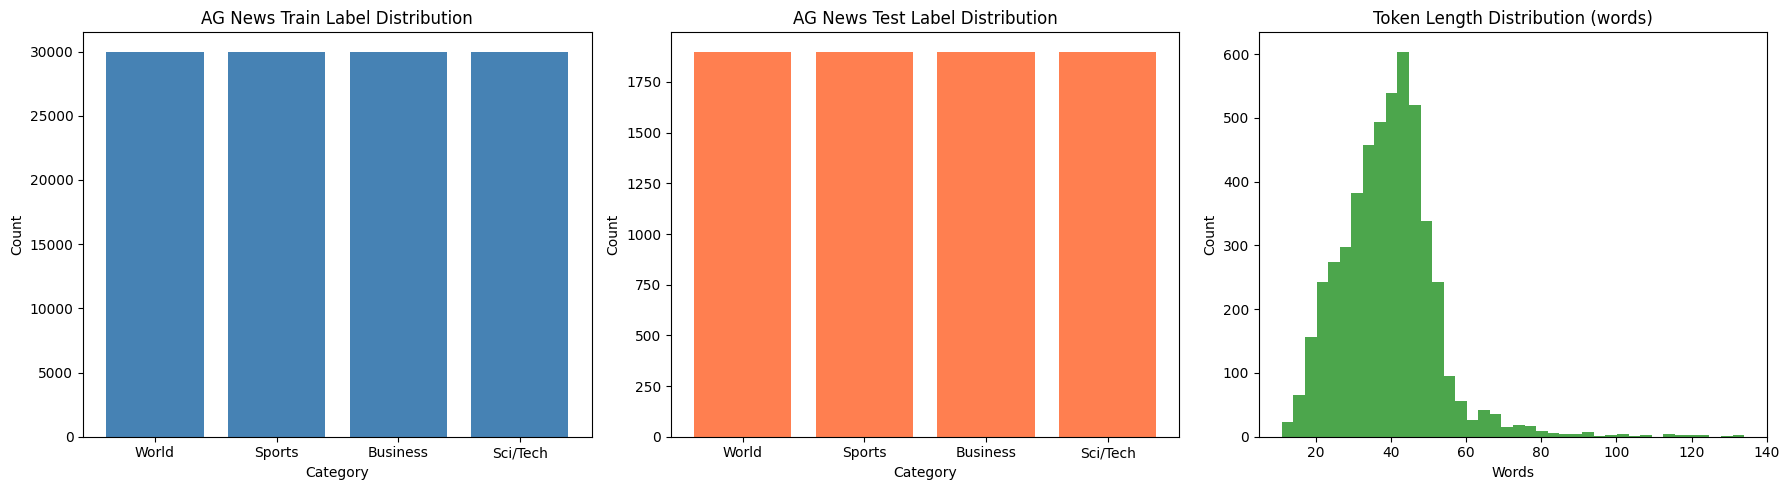

Mean text length: 39.2 words | Max: 134 | Min: 11


In [4]:
# EDA: Label Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

train_labels = ag_news['train']['label']
test_labels  = ag_news['test']['label']
train_counts = pd.Series(train_labels).value_counts().sort_index()
test_counts  = pd.Series(test_labels).value_counts().sort_index()

axes[0].bar([label_names[i] for i in train_counts.index], train_counts.values, color='steelblue')
axes[0].set_title('AG News Train Label Distribution')
axes[0].set_xlabel('Category'); axes[0].set_ylabel('Count')

axes[1].bar([label_names[i] for i in test_counts.index], test_counts.values, color='coral')
axes[1].set_title('AG News Test Label Distribution')
axes[1].set_xlabel('Category'); axes[1].set_ylabel('Count')

# Text length distribution
lengths = [len(t.split()) for t in ag_news['train']['text'][:5000]]
axes[2].hist(lengths, bins=40, color='green', alpha=0.7)
axes[2].set_title('Token Length Distribution (words)')
axes[2].set_xlabel('Words'); axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('ag_news_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Mean text length: {np.mean(lengths):.1f} words | Max: {max(lengths)} | Min: {min(lengths)}')


### 2.2 Shared Tokenization and Helper Functions


In [5]:
metric_acc = evaluate.load('accuracy')
metric_f1  = evaluate.load('f1')

def compute_metrics_cls(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=preds, references=labels)['accuracy']
    f1  = metric_f1.compute(predictions=preds, references=labels, average='weighted')['f1']
    return {'accuracy': acc, 'f1': f1}

def tokenize_dataset(dataset, tokenizer, max_length=128):
    def _tok(examples):
        return tokenizer(examples['text'], padding='max_length',
                         truncation=True, max_length=max_length)
    tok_ds = dataset.map(_tok, batched=True, remove_columns=['text'])
    tok_ds.set_format('torch')
    return tok_ds

def evaluate_baseline(model_name, tokenized_test):

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=4, id2label=id2label, label2id=label2id
    ).to(device)
    model.eval()
    subset = tokenized_test.select(range(500))
    preds, labels_all = [], []
    for i in range(0, len(subset), 64):
        batch = subset[i:i+64]
        ids   = batch['input_ids'].to(device)
        mask  = batch['attention_mask'].to(device)
        with torch.no_grad():
            out = model(input_ids=ids, attention_mask=mask)
        preds.extend(out.logits.argmax(-1).cpu().tolist())
        lbl = batch['label']
        labels_all.extend(lbl.tolist() if hasattr(lbl, 'tolist') else list(lbl))
    del model; torch.cuda.empty_cache()
    acc = accuracy_score(labels_all, preds)
    f1  = f1_score(labels_all, preds, average='weighted')
    return acc, f1

def build_lora_cls(base_model_name, target_modules, r=8, alpha=16, dropout=0.1):
    model = AutoModelForSequenceClassification.from_pretrained(
        base_model_name, num_labels=4, id2label=id2label, label2id=label2id
    )
    cfg = LoraConfig(
        task_type=TaskType.SEQ_CLS, r=r, lora_alpha=alpha,
        lora_dropout=dropout, target_modules=target_modules, bias='none'
    )
    model = get_peft_model(model, cfg)
    model.print_trainable_parameters()
    return model

def get_training_history(trainer):
    logs = trainer.state.log_history
    train_loss, eval_loss, eval_acc, eval_f1, steps, epochs = [], [], [], [], [], []
    for log in logs:
        if 'loss' in log and 'eval_loss' not in log:
            train_loss.append(log['loss']); steps.append(log['step'])
        if 'eval_loss' in log:
            eval_loss.append(log['eval_loss'])
            eval_acc.append(log.get('eval_accuracy', 0))
            eval_f1.append(log.get('eval_f1', 0))
            epochs.append(log['epoch'])
    return dict(train_loss=train_loss, eval_loss=eval_loss, eval_accuracy=eval_acc,
                eval_f1=eval_f1, steps=steps, epochs=epochs)

print('Helper functions defined.')

Helper functions defined.


### 2.3 Model 1: DistilBERT + LoRA


In [6]:
MODEL1 = 'distilbert-base-uncased'
tokenizer1 = AutoTokenizer.from_pretrained(MODEL1)
tok_train1 = tokenize_dataset(ag_news['train'], tokenizer1)
tok_test1  = tokenize_dataset(ag_news['test'],  tokenizer1)
print('DistilBERT tokenization done.')
print(f'Train features: {tok_train1.features}')


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

DistilBERT tokenization done.
Train features: {'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech']), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


In [7]:
print('--- DistilBERT BEFORE fine-tuning (random classification head) ---')
acc_b1, f1_b1 = evaluate_baseline(MODEL1, tok_test1)
print(f'Baseline Accuracy: {acc_b1:.4f} | F1: {f1_b1:.4f}')


--- DistilBERT BEFORE fine-tuning (random classification head) ---


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Baseline Accuracy: 0.2940 | F1: 0.1754


In [8]:
print('=' * 60)
print('DistilBERT Trial 1: lr=2e-4, batch=32, epochs=3, r=8, alpha=16')
print('=' * 60)

m1_t1 = build_lora_cls(MODEL1, target_modules=['q_lin', 'v_lin'],
                        r=8, alpha=16, dropout=0.1).to(device)

args1_t1 = TrainingArguments(
    output_dir='./ckpt/distilbert_t1',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-4,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_steps=250,
    warmup_ratio=0.1,
    report_to='none',
    fp16=torch.cuda.is_available(),
)

trainer1_t1 = Trainer(
    model=m1_t1, args=args1_t1,
    train_dataset=tok_train1, eval_dataset=tok_test1,
    tokenizer=tokenizer1,
    data_collator=DataCollatorWithPadding(tokenizer1),
    compute_metrics=compute_metrics_cls,
)
trainer1_t1.train()
res1_t1 = trainer1_t1.evaluate()
print(f'Trial 1 => Accuracy: {res1_t1["eval_accuracy"]:.4f} | F1: {res1_t1["eval_f1"]:.4f} | Loss: {res1_t1["eval_loss"]:.4f}')


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBERT Trial 1: lr=2e-4, batch=32, epochs=3, r=8, alpha=16
trainable params: 741,124 || all params: 67,697,672 || trainable%: 1.0948


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.218900,0.206974,0.926579,0.926542
2,0.186600,0.185368,0.935789,0.935851
3,0.162500,0.181462,0.937895,0.937893


Trial 1 => Accuracy: 0.9379 | F1: 0.9379 | Loss: 0.1815


In [9]:
print('=' * 60)
print('DistilBERT Trial 2: lr=5e-5, batch=16, epochs=5, r=16, alpha=32')
print('=' * 60)

m1_t2 = build_lora_cls(MODEL1, target_modules=['q_lin', 'v_lin'],
                        r=16, alpha=32, dropout=0.05).to(device)

args1_t2 = TrainingArguments(
    output_dir='./ckpt/distilbert_t2',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    learning_rate=5e-5,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_steps=500,
    warmup_ratio=0.1,
    report_to='none',
    fp16=torch.cuda.is_available(),
)

trainer1_t2 = Trainer(
    model=m1_t2, args=args1_t2,
    train_dataset=tok_train1, eval_dataset=tok_test1,
    tokenizer=tokenizer1,
    data_collator=DataCollatorWithPadding(tokenizer1),
    compute_metrics=compute_metrics_cls,
)
trainer1_t2.train()
res1_t2 = trainer1_t2.evaluate()
print(f'Trial 2 => Accuracy: {res1_t2["eval_accuracy"]:.4f} | F1: {res1_t2["eval_f1"]:.4f} | Loss: {res1_t2["eval_loss"]:.4f}')


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBERT Trial 2: lr=5e-5, batch=16, epochs=5, r=16, alpha=32
trainable params: 888,580 || all params: 67,845,128 || trainable%: 1.3097


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.247900,0.230359,0.921579,0.921591
2,0.207700,0.208935,0.930263,0.930250
3,0.186200,0.200154,0.935000,0.934958
4,0.177400,0.198075,0.935921,0.935926
5,0.167700,0.196756,0.937368,0.937400


Trial 2 => Accuracy: 0.9374 | F1: 0.9374 | Loss: 0.1968


### 2.4 Model 2: RoBERTa + LoRA


In [10]:
MODEL2 = 'roberta-base'
tokenizer2 = AutoTokenizer.from_pretrained(MODEL2)
tok_train2 = tokenize_dataset(ag_news['train'], tokenizer2)
tok_test2  = tokenize_dataset(ag_news['test'],  tokenizer2)
print('RoBERTa tokenization done.')


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

RoBERTa tokenization done.


In [11]:
print(' RoBERTa BEFORE fine-tuning ')
acc_b2, f1_b2 = evaluate_baseline(MODEL2, tok_test2)
print(f'Baseline Accuracy: {acc_b2:.4f} | F1: {f1_b2:.4f}')


--- RoBERTa BEFORE fine-tuning ---


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Baseline Accuracy: 0.2120 | F1: 0.0742


In [12]:
print('=' * 60)
print('RoBERTa Trial 1: lr=2e-4, batch=32, epochs=3, r=8, alpha=16')
print('=' * 60)

m2_t1 = build_lora_cls(MODEL2, target_modules=['query', 'value'],
                        r=8, alpha=16, dropout=0.1).to(device)

args2_t1 = TrainingArguments(
    output_dir='./ckpt/roberta_t1',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-4,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_steps=250,
    warmup_ratio=0.1,
    report_to='none',
    fp16=torch.cuda.is_available(),
)

trainer2_t1 = Trainer(
    model=m2_t1, args=args2_t1,
    train_dataset=tok_train2, eval_dataset=tok_test2,
    tokenizer=tokenizer2,
    data_collator=DataCollatorWithPadding(tokenizer2),
    compute_metrics=compute_metrics_cls,
)
trainer2_t1.train()
res2_t1 = trainer2_t1.evaluate()
print(f'Trial 1 => Accuracy: {res2_t1["eval_accuracy"]:.4f} | F1: {res2_t1["eval_f1"]:.4f} | Loss: {res2_t1["eval_loss"]:.4f}')


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RoBERTa Trial 1: lr=2e-4, batch=32, epochs=3, r=8, alpha=16
trainable params: 888,580 || all params: 125,537,288 || trainable%: 0.7078


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.213600,0.195883,0.933553,0.933485
2,0.180900,0.179092,0.939868,0.939944
3,0.156900,0.174728,0.940789,0.940764


Trial 1 => Accuracy: 0.9408 | F1: 0.9408 | Loss: 0.1747


In [13]:
print('=' * 60)
print('RoBERTa Trial 2: lr=1e-4, batch=16, epochs=5, r=16, alpha=32')
print('=' * 60)

m2_t2 = build_lora_cls(MODEL2, target_modules=['query', 'value'],
                        r=16, alpha=32, dropout=0.05).to(device)

args2_t2 = TrainingArguments(
    output_dir='./ckpt/roberta_t2',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    learning_rate=1e-4,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    logging_steps=500,
    warmup_ratio=0.1,
    report_to='none',
    fp16=torch.cuda.is_available(),
)

trainer2_t2 = Trainer(
    model=m2_t2, args=args2_t2,
    train_dataset=tok_train2, eval_dataset=tok_test2,
    tokenizer=tokenizer2,
    data_collator=DataCollatorWithPadding(tokenizer2),
    compute_metrics=compute_metrics_cls,
)
trainer2_t2.train()
res2_t2 = trainer2_t2.evaluate()
print(f'Trial 2 => Accuracy: {res2_t2["eval_accuracy"]:.4f} | F1: {res2_t2["eval_f1"]:.4f} | Loss: {res2_t2["eval_loss"]:.4f}')


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RoBERTa Trial 2: lr=1e-4, batch=16, epochs=5, r=16, alpha=32
trainable params: 1,183,492 || all params: 125,832,200 || trainable%: 0.9405


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.234900,0.211259,0.930395,0.930472
2,0.193400,0.187585,0.940395,0.940397
3,0.171000,0.183939,0.942895,0.942769
4,0.157700,0.181548,0.944474,0.944468
5,0.139800,0.180968,0.945395,0.945358


Trial 2 => Accuracy: 0.9454 | F1: 0.9454 | Loss: 0.1810


### 2.5 Classification Results — Visualisations and Summary


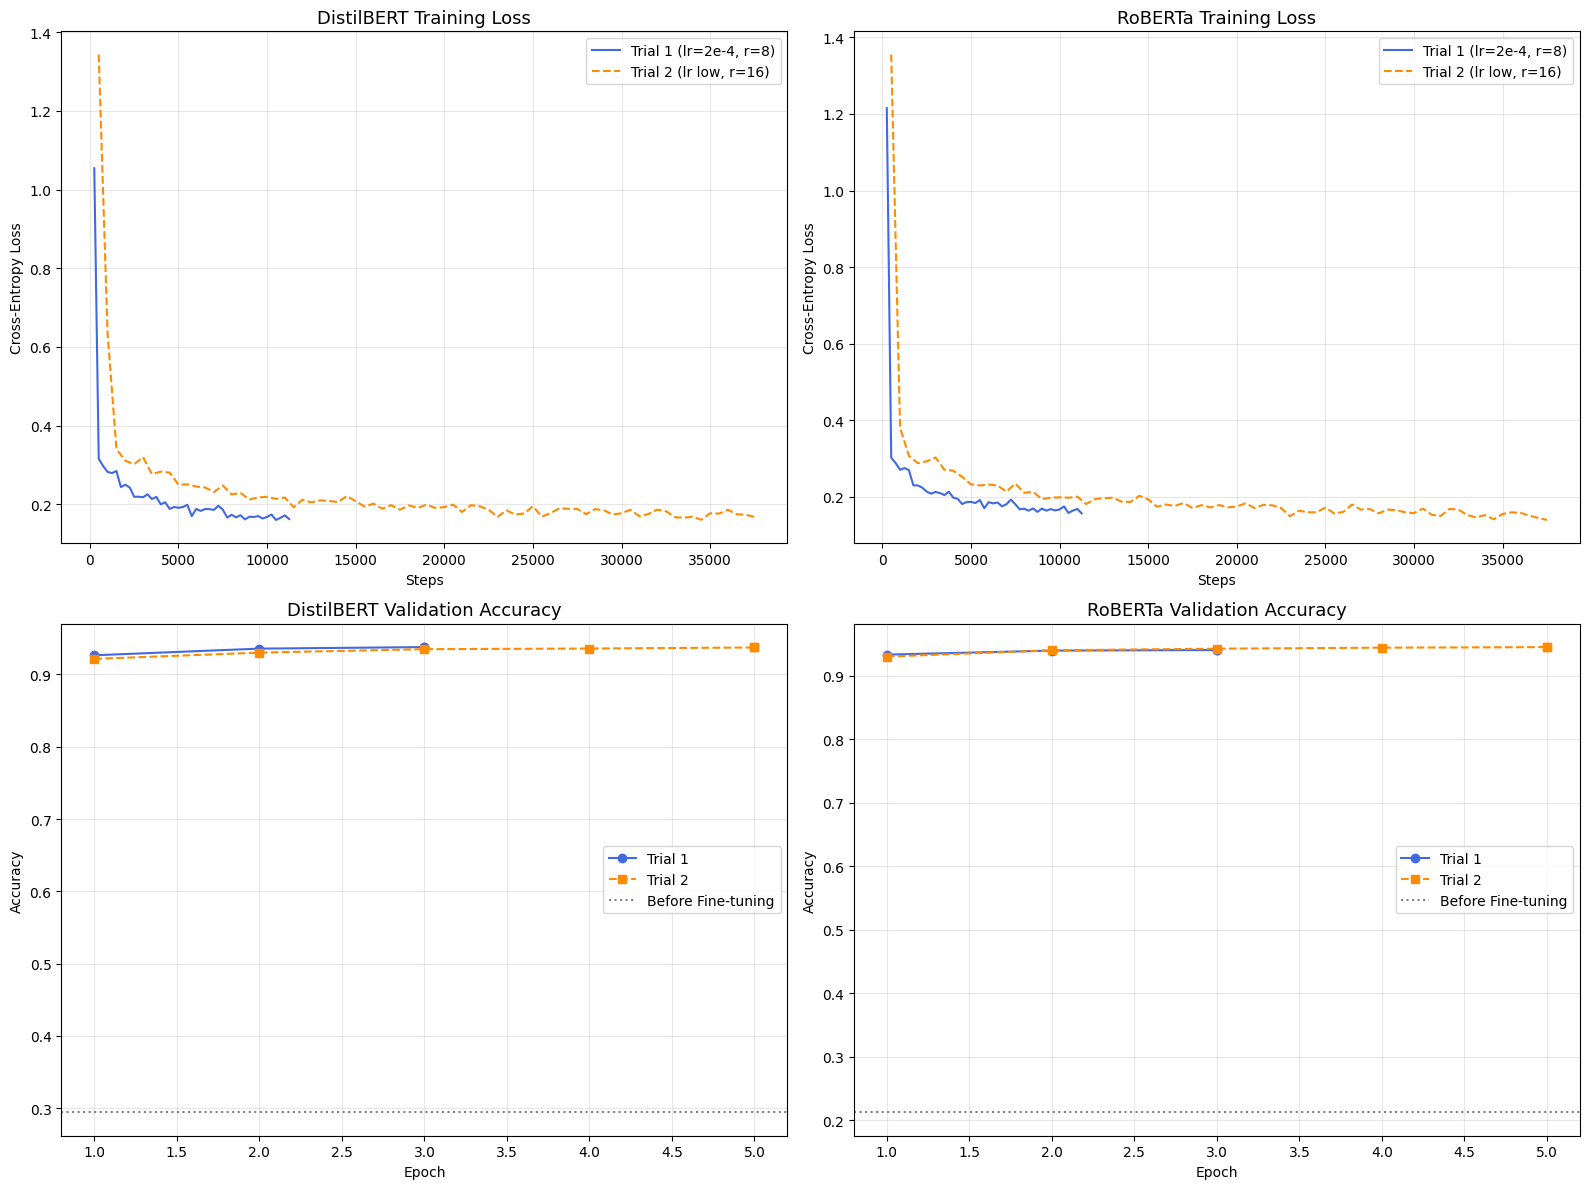

Classification training curves saved.


In [14]:
h1t1 = get_training_history(trainer1_t1)
h1t2 = get_training_history(trainer1_t2)
h2t1 = get_training_history(trainer2_t1)
h2t2 = get_training_history(trainer2_t2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Training loss
for ax, hist_a, hist_b, title in [
    (axes[0,0], h1t1, h1t2, 'DistilBERT Training Loss'),
    (axes[0,1], h2t1, h2t2, 'RoBERTa Training Loss'),
]:
    ax.plot(hist_a['steps'], hist_a['train_loss'], label='Trial 1 (lr=2e-4, r=8)', color='royalblue')
    ax.plot(hist_b['steps'], hist_b['train_loss'], label='Trial 2 (lr low, r=16)', color='darkorange', linestyle='--')
    ax.set_title(title, fontsize=13); ax.set_xlabel('Steps'); ax.set_ylabel('Cross-Entropy Loss')
    ax.legend(); ax.grid(alpha=0.3)

# Validation accuracy per epoch
for ax, hist_a, hist_b, acc_b, title in [
    (axes[1,0], h1t1, h1t2, acc_b1, 'DistilBERT Validation Accuracy'),
    (axes[1,1], h2t1, h2t2, acc_b2, 'RoBERTa Validation Accuracy'),
]:
    ax.plot(hist_a['epochs'], hist_a['eval_accuracy'], 'o-', label='Trial 1', color='royalblue')
    ax.plot(hist_b['epochs'], hist_b['eval_accuracy'], 's--', label='Trial 2', color='darkorange')
    ax.axhline(acc_b, color='gray', linestyle=':', label='Before Fine-tuning')
    ax.set_title(title, fontsize=13); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('classification_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Classification training curves saved.')


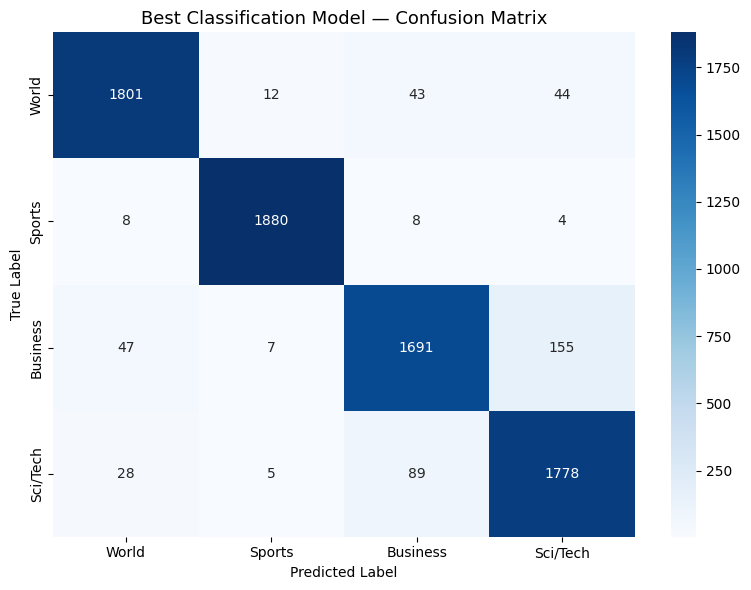


Classification Report:
              precision    recall  f1-score   support

       World       0.96      0.95      0.95      1900
      Sports       0.99      0.99      0.99      1900
    Business       0.92      0.89      0.91      1900
    Sci/Tech       0.90      0.94      0.92      1900

    accuracy                           0.94      7600
   macro avg       0.94      0.94      0.94      7600
weighted avg       0.94      0.94      0.94      7600



In [15]:
# Confusion matrix for best performing model (expected: RoBERTa Trial 1 or 2)
# We use whichever trainer produced the best accuracy
best_trainer_cls = trainer2_t1  # update after running ,pick highest accuracy

preds_out = best_trainer_cls.predict(tok_test2)
y_pred = np.argmax(preds_out.predictions, axis=-1)
y_true = preds_out.label_ids

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_title('Best Classification Model — Confusion Matrix', fontsize=13)
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=label_names))


In [16]:
# Summary table
summary_cls = pd.DataFrame({
    'Model':         ['DistilBERT','DistilBERT','DistilBERT','RoBERTa','RoBERTa','RoBERTa'],
    'Configuration': ['Before FT','Trial1(lr=2e-4,r=8,ep=3)','Trial2(lr=5e-5,r=16,ep=5)',
                       'Before FT','Trial1(lr=2e-4,r=8,ep=3)','Trial2(lr=1e-4,r=16,ep=5)'],
    'Accuracy':      [f'{acc_b1:.4f}', f'{res1_t1["eval_accuracy"]:.4f}', f'{res1_t2["eval_accuracy"]:.4f}',
                       f'{acc_b2:.4f}', f'{res2_t1["eval_accuracy"]:.4f}', f'{res2_t2["eval_accuracy"]:.4f}'],
    'F1 (Weighted)': [f'{f1_b1:.4f}',  f'{res1_t1["eval_f1"]:.4f}',       f'{res1_t2["eval_f1"]:.4f}',
                       f'{f1_b2:.4f}',  f'{res2_t1["eval_f1"]:.4f}',       f'{res2_t2["eval_f1"]:.4f}'],
    'Eval Loss':     ['N/A', f'{res1_t1["eval_loss"]:.4f}', f'{res1_t2["eval_loss"]:.4f}',
                       'N/A', f'{res2_t1["eval_loss"]:.4f}', f'{res2_t2["eval_loss"]:.4f}'],
})
print('\n' + '='*80)
print('CLASSIFICATION RESULTS SUMMARY')
print('='*80)
print(summary_cls.to_string(index=False))



CLASSIFICATION RESULTS SUMMARY
     Model             Configuration Accuracy F1 (Weighted) Eval Loss
DistilBERT                 Before FT   0.2940        0.1754       N/A
DistilBERT  Trial1(lr=2e-4,r=8,ep=3)   0.9379        0.9379    0.1815
DistilBERT Trial2(lr=5e-5,r=16,ep=5)   0.9374        0.9374    0.1968
   RoBERTa                 Before FT   0.2120        0.0742       N/A
   RoBERTa  Trial1(lr=2e-4,r=8,ep=3)   0.9408        0.9408    0.1747
   RoBERTa Trial2(lr=1e-4,r=16,ep=5)   0.9454        0.9454    0.1810


---
## Section 3: Task 2 — PersonaChat Dialogue Generation
### 3.1 Dataset Loading and Exploratory Data Analysis


In [17]:
print('Loading PersonaChat dataset (full 17.9k train / 1k validation)...')
persona_chat = load_dataset('AlekseyKorshuk/persona-chat')
print(persona_chat)
print(f'\nTrain size: {len(persona_chat["train"])}')
print(f'Validation size: {len(persona_chat["validation"])}')
print('\n--- Sample entry ---')
sample = persona_chat['train'][0]
print('Personality:', sample['personality'])
print('\nUtterances[0]:')
print('  History:', sample['utterances'][0]['history'])
print('  Candidates (last = ground truth):', sample['utterances'][0]['candidates'][-1])


Loading PersonaChat dataset (full 17.9k train / 1k validation)...


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/97.5M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/4.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/17878 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['personality', 'utterances'],
        num_rows: 17878
    })
    validation: Dataset({
        features: ['personality', 'utterances'],
        num_rows: 1000
    })
})

Train size: 17878
Validation size: 1000

--- Sample entry ---
Personality: ['i like to remodel homes .', 'i like to go hunting .', 'i like to shoot a bow .', 'my favorite holiday is halloween .']

Utterances[0]:
  History: ["hi , how are you doing ? i'm getting ready to do some cheetah chasing to stay in shape ."]
  Candidates (last = ground truth): you must be very fast . hunting is one of my favorite hobbies .


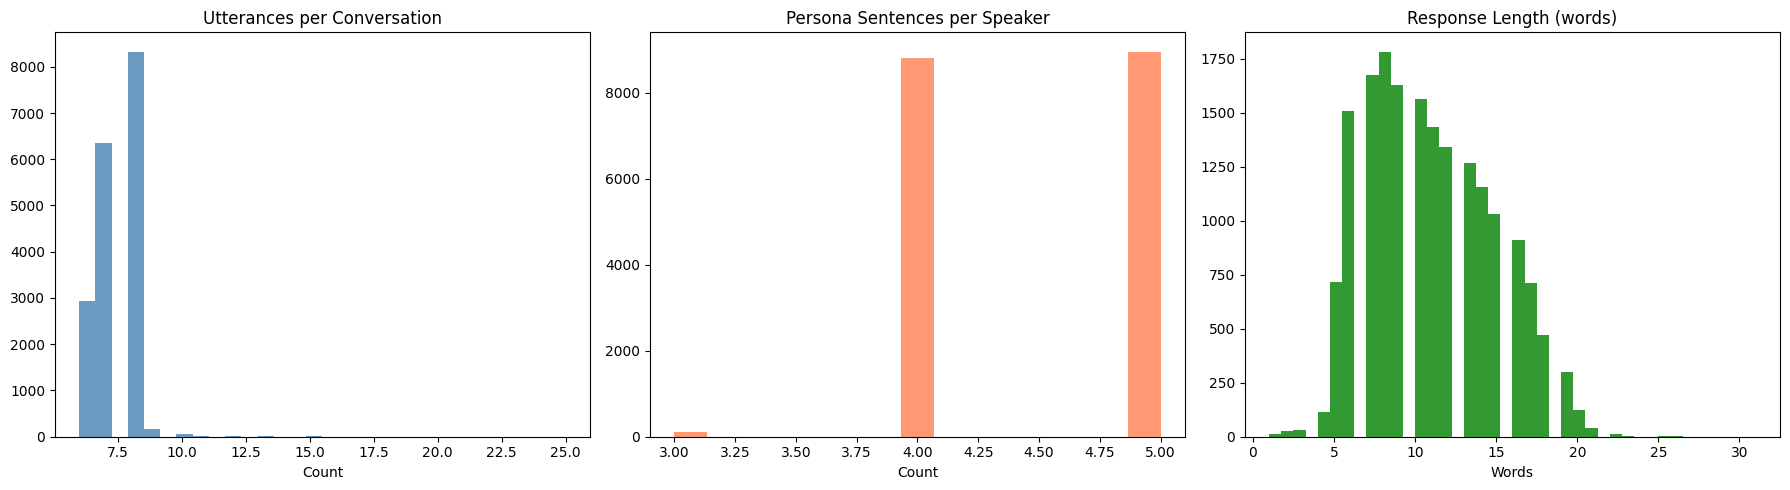

Avg utterances/conv: 7.4
Avg persona stmts:   4.5
Avg response length: 10.9 words


In [18]:
# EDA for PersonaChat
num_utterances  = [len(item['utterances']) for item in persona_chat['train']]
num_persona_str = [len(item['personality']) for item in persona_chat['train']]
response_lens   = [len(item['utterances'][-1]['candidates'][-1].split())
                   for item in persona_chat['train']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].hist(num_utterances, bins=30, color='steelblue', alpha=0.8)
axes[0].set_title('Utterances per Conversation'); axes[0].set_xlabel('Count')
axes[1].hist(num_persona_str, bins=15, color='coral', alpha=0.8)
axes[1].set_title('Persona Sentences per Speaker'); axes[1].set_xlabel('Count')
axes[2].hist(response_lens, bins=40, color='green', alpha=0.8)
axes[2].set_title('Response Length (words)'); axes[2].set_xlabel('Words')
plt.tight_layout()
plt.savefig('persona_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Avg utterances/conv: {np.mean(num_utterances):.1f}')
print(f'Avg persona stmts:   {np.mean(num_persona_str):.1f}')
print(f'Avg response length: {np.mean(response_lens):.1f} words')


### 3.2 PersonaChat Data Preprocessing
We convert each dialogue turn into a single training string:
`[PERSONA] ... [HISTORY] ... [RESPONSE] <ground_truth_response>`


In [19]:
def build_persona_texts(split_data):
    """Convert PersonaChat conversations to flat training strings."""
    texts = []
    for item in split_data:
        persona_str = ' '.join([f'[PERSONA] {p}' for p in item['personality']])
        for utt in item['utterances']:
            history  = utt['history']
            response = utt['candidates'][-1]

            history_str = ' [SEP] '.join(history[-4:])
            text = f'{persona_str} [HISTORY] {history_str} [RESPONSE] {response}'
            texts.append(text)
    return texts

train_texts_gen = build_persona_texts(persona_chat['train'])
val_texts_gen   = build_persona_texts(persona_chat['validation'])
print(f'Training examples: {len(train_texts_gen)}')
print(f'Validation examples: {len(val_texts_gen)}')
print(f'\nSample (first 250 chars):\n{train_texts_gen[0][:250]}...')


Training examples: 131438
Validation examples: 7801

Sample (first 250 chars):
[PERSONA] i like to remodel homes . [PERSONA] i like to go hunting . [PERSONA] i like to shoot a bow . [PERSONA] my favorite holiday is halloween . [HISTORY] hi , how are you doing ? i'm getting ready to do some cheetah chasing to stay in shape . [RE...


In [20]:
class PersonaChatDataset(TorchDataset):
    """PyTorch Dataset for PersonaChat causal language modelling."""
    def __init__(self, texts, tokenizer, max_length=256):
        enc = tokenizer(
            texts, max_length=max_length, truncation=True,
            padding='max_length', return_tensors='pt'
        )
        self.input_ids      = enc['input_ids']
        self.attention_mask = enc['attention_mask']

    def __len__(self):  return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
        }

def build_lora_gen(base_model_name, r=8, alpha=16, dropout=0.1):
    model = AutoModelForCausalLM.from_pretrained(base_model_name)
    cfg = LoraConfig(
        task_type=TaskType.CAUSAL_LM, r=r, lora_alpha=alpha,
        lora_dropout=dropout, target_modules=['c_attn'], bias='none'
    )
    model = get_peft_model(model, cfg)
    model.print_trainable_parameters()
    return model

def perplexity_from_trainer_eval(eval_loss):
    return round(np.exp(eval_loss), 2)

rouge_metric = evaluate.load('rouge')

def compute_rouge(model, tokenizer, val_texts, n=200):
    model.eval()
    preds, refs = [], []
    for txt in val_texts[:n]:
        if '[RESPONSE]' not in txt:
            continue
        ctx, ref = txt.split('[RESPONSE]', 1)
        ref = ref.strip()
        enc = tokenizer(ctx + '[RESPONSE]', return_tensors='pt',
                        max_length=200, truncation=True).to(device)
        with torch.no_grad():
            out = model.generate(
                **enc, max_new_tokens=50, do_sample=True,
                temperature=0.7, top_p=0.9,
                pad_token_id=tokenizer.eos_token_id
            )
        gen_tokens = out[0][enc['input_ids'].shape[1]:]
        gen_text   = tokenizer.decode(gen_tokens, skip_special_tokens=True)
        preds.append(gen_text)
        refs.append(ref)
    return rouge_metric.compute(predictions=preds, references=refs)

def compute_perplexity_pre(model_name, tokenizer, val_ds, n_batches=50):
    model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
    model.eval()
    total_loss, count = 0.0, 0
    for i in range(min(n_batches, len(val_ds))):
        ids  = val_ds[i]['input_ids'].unsqueeze(0).to(device)
        with torch.no_grad():
            total_loss += model(input_ids=ids, labels=ids).loss.item()
            count += 1
    del model; torch.cuda.empty_cache()
    return perplexity_from_trainer_eval(total_loss / count)

print('Generation helper functions defined.')


Generation helper functions defined.


### 3.3 Model 3: DialoGPT-small + LoRA


In [21]:
GEN_MODEL1 = 'microsoft/DialoGPT-small'
tok_gen1 = AutoTokenizer.from_pretrained(GEN_MODEL1)
tok_gen1.pad_token = tok_gen1.eos_token

train_ds_gen1 = PersonaChatDataset(train_texts_gen, tok_gen1, max_length=256)
val_ds_gen1   = PersonaChatDataset(val_texts_gen,   tok_gen1, max_length=256)
print(f'DialoGPT-small datasets ready. Train: {len(train_ds_gen1)} | Val: {len(val_ds_gen1)}')

print('\n--- DialoGPT-small BEFORE fine-tuning ---')
ppl_before_g1 = compute_perplexity_pre(GEN_MODEL1, tok_gen1, val_ds_gen1)
print(f'Baseline Perplexity: {ppl_before_g1}')


tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

DialoGPT-small datasets ready. Train: 131438 | Val: 7801

--- DialoGPT-small BEFORE fine-tuning ---


config.json:   0%|          | 0.00/641 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/351M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Baseline Perplexity: 318.55


In [22]:
print('=' * 60)
print('DialoGPT-small Trial 1: lr=2e-4, batch=8, epochs=3, r=8, alpha=16')
print('=' * 60)

gen1_t1 = build_lora_gen(GEN_MODEL1, r=8, alpha=16, dropout=0.1).to(device)
collator_g1 = DataCollatorForLanguageModeling(tokenizer=tok_gen1, mlm=False)

gen_args1_t1 = TrainingArguments(
    output_dir='./ckpt/dialogpt_t1',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    logging_steps=100,
    warmup_ratio=0.1,
    report_to='none',
    fp16=torch.cuda.is_available(),
)

trainer_g1_t1 = Trainer(
    model=gen1_t1, args=gen_args1_t1,
    train_dataset=train_ds_gen1, eval_dataset=val_ds_gen1,
    data_collator=collator_g1,
)
trainer_g1_t1.train()
res_g1_t1 = trainer_g1_t1.evaluate()
ppl_g1_t1 = perplexity_from_trainer_eval(res_g1_t1['eval_loss'])
print(f'Trial 1 => Loss: {res_g1_t1["eval_loss"]:.4f} | Perplexity: {ppl_g1_t1}')

print('Computing ROUGE scores...')
rouge_g1_t1 = compute_rouge(gen1_t1, tok_gen1, val_texts_gen)
print(f'ROUGE-1: {rouge_g1_t1["rouge1"]:.4f} | ROUGE-2: {rouge_g1_t1["rouge2"]:.4f} | ROUGE-L: {rouge_g1_t1["rougeL"]:.4f}')


DialoGPT-small Trial 1: lr=2e-4, batch=8, epochs=3, r=8, alpha=16
trainable params: 294,912 || all params: 124,734,720 || trainable%: 0.2364


Epoch,Training Loss,Validation Loss
1,2.135500,2.059582
2,2.083000,2.045817
3,2.046900,2.047612


Trial 1 => Loss: 2.0458 | Perplexity: 7.74
Computing ROUGE scores...
ROUGE-1: 0.1668 | ROUGE-2: 0.0399 | ROUGE-L: 0.1448


In [23]:
print('=' * 60)
print('DialoGPT-small Trial 2: lr=5e-5, batch=4, epochs=5, r=16, alpha=32')
print('=' * 60)

gen1_t2 = build_lora_gen(GEN_MODEL1, r=16, alpha=32, dropout=0.05).to(device)

gen_args1_t2 = TrainingArguments(
    output_dir='./ckpt/dialogpt_t2',
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    learning_rate=5e-5,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    logging_steps=200,
    warmup_ratio=0.1,
    report_to='none',
    fp16=torch.cuda.is_available(),
)

trainer_g1_t2 = Trainer(
    model=gen1_t2, args=gen_args1_t2,
    train_dataset=train_ds_gen1, eval_dataset=val_ds_gen1,
    data_collator=collator_g1,
)
trainer_g1_t2.train()
res_g1_t2 = trainer_g1_t2.evaluate()
ppl_g1_t2 = perplexity_from_trainer_eval(res_g1_t2['eval_loss'])
print(f'Trial 2 => Loss: {res_g1_t2["eval_loss"]:.4f} | Perplexity: {ppl_g1_t2}')

rouge_g1_t2 = compute_rouge(gen1_t2, tok_gen1, val_texts_gen)
print(f'ROUGE-1: {rouge_g1_t2["rouge1"]:.4f} | ROUGE-2: {rouge_g1_t2["rouge2"]:.4f} | ROUGE-L: {rouge_g1_t2["rougeL"]:.4f}')


DialoGPT-small Trial 2: lr=5e-5, batch=4, epochs=5, r=16, alpha=32
trainable params: 589,824 || all params: 125,029,632 || trainable%: 0.4717


Epoch,Training Loss,Validation Loss
1,2.219900,2.091740
2,2.132500,2.058276
3,2.085000,2.049052
4,2.084300,2.048799
5,2.079100,2.046834


Trial 2 => Loss: 2.0468 | Perplexity: 7.74
ROUGE-1: 0.1535 | ROUGE-2: 0.0370 | ROUGE-L: 0.1340


### 3.4 Model 4: GPT-2 + LoRA


In [24]:
GEN_MODEL2 = 'gpt2'
tok_gen2 = AutoTokenizer.from_pretrained(GEN_MODEL2)
tok_gen2.pad_token = tok_gen2.eos_token

train_ds_gen2 = PersonaChatDataset(train_texts_gen, tok_gen2, max_length=256)
val_ds_gen2   = PersonaChatDataset(val_texts_gen,   tok_gen2, max_length=256)

print('--- GPT-2 BEFORE fine-tuning ---')
ppl_before_g2 = compute_perplexity_pre(GEN_MODEL2, tok_gen2, val_ds_gen2)
print(f'Baseline Perplexity: {ppl_before_g2}')


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

--- GPT-2 BEFORE fine-tuning ---


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Baseline Perplexity: 7087.63


In [25]:
print('=' * 60)
print('GPT-2 Trial 1: lr=2e-4, batch=8, epochs=3, r=8, alpha=16')
print('=' * 60)

gen2_t1 = build_lora_gen(GEN_MODEL2, r=8, alpha=16, dropout=0.1).to(device)
collator_g2 = DataCollatorForLanguageModeling(tokenizer=tok_gen2, mlm=False)

gen_args2_t1 = TrainingArguments(
    output_dir='./ckpt/gpt2_t1',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    logging_steps=100,
    warmup_ratio=0.1,
    report_to='none',
    fp16=torch.cuda.is_available(),
)

trainer_g2_t1 = Trainer(
    model=gen2_t1, args=gen_args2_t1,
    train_dataset=train_ds_gen2, eval_dataset=val_ds_gen2,
    data_collator=collator_g2,
)
trainer_g2_t1.train()
res_g2_t1 = trainer_g2_t1.evaluate()
ppl_g2_t1 = perplexity_from_trainer_eval(res_g2_t1['eval_loss'])
print(f'Trial 1 => Loss: {res_g2_t1["eval_loss"]:.4f} | Perplexity: {ppl_g2_t1}')

rouge_g2_t1 = compute_rouge(gen2_t1, tok_gen2, val_texts_gen)
print(f'ROUGE-1: {rouge_g2_t1["rouge1"]:.4f} | ROUGE-2: {rouge_g2_t1["rouge2"]:.4f} | ROUGE-L: {rouge_g2_t1["rougeL"]:.4f}')


GPT-2 Trial 1: lr=2e-4, batch=8, epochs=3, r=8, alpha=16
trainable params: 294,912 || all params: 124,734,720 || trainable%: 0.2364


Epoch,Training Loss,Validation Loss
1,2.087600,2.091709
2,2.043100,2.090592
3,2.012600,2.093140


Trial 1 => Loss: 2.0906 | Perplexity: 8.09
ROUGE-1: 0.1594 | ROUGE-2: 0.0333 | ROUGE-L: 0.1428


In [26]:
print('=' * 60)
print('GPT-2 Trial 2: lr=1e-4, batch=4, epochs=5, r=16, alpha=32')
print('=' * 60)

gen2_t2 = build_lora_gen(GEN_MODEL2, r=16, alpha=32, dropout=0.05).to(device)

gen_args2_t2 = TrainingArguments(
    output_dir='./ckpt/gpt2_t2',
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    weight_decay=0.01,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    logging_steps=200,
    warmup_ratio=0.1,
    report_to='none',
    fp16=torch.cuda.is_available(),
)

trainer_g2_t2 = Trainer(
    model=gen2_t2, args=gen_args2_t2,
    train_dataset=train_ds_gen2, eval_dataset=val_ds_gen2,
    data_collator=collator_g2,
)
trainer_g2_t2.train()
res_g2_t2 = trainer_g2_t2.evaluate()
ppl_g2_t2 = perplexity_from_trainer_eval(res_g2_t2['eval_loss'])
print(f'Trial 2 => Loss: {res_g2_t2["eval_loss"]:.4f} | Perplexity: {ppl_g2_t2}')

rouge_g2_t2 = compute_rouge(gen2_t2, tok_gen2, val_texts_gen)
print(f'ROUGE-1: {rouge_g2_t2["rouge1"]:.4f} | ROUGE-2: {rouge_g2_t2["rouge2"]:.4f} | ROUGE-L: {rouge_g2_t2["rougeL"]:.4f}')


GPT-2 Trial 2: lr=1e-4, batch=4, epochs=5, r=16, alpha=32
trainable params: 589,824 || all params: 125,029,632 || trainable%: 0.4717


Epoch,Training Loss,Validation Loss
1,2.099600,2.097110
2,2.028700,2.089573
3,1.980200,2.099051
4,1.974600,2.104031
5,1.964500,2.108079


Trial 2 => Loss: 2.0896 | Perplexity: 8.08
ROUGE-1: 0.1738 | ROUGE-2: 0.0409 | ROUGE-L: 0.1517


### 3.5 Generation Results — Visualisations and Summary


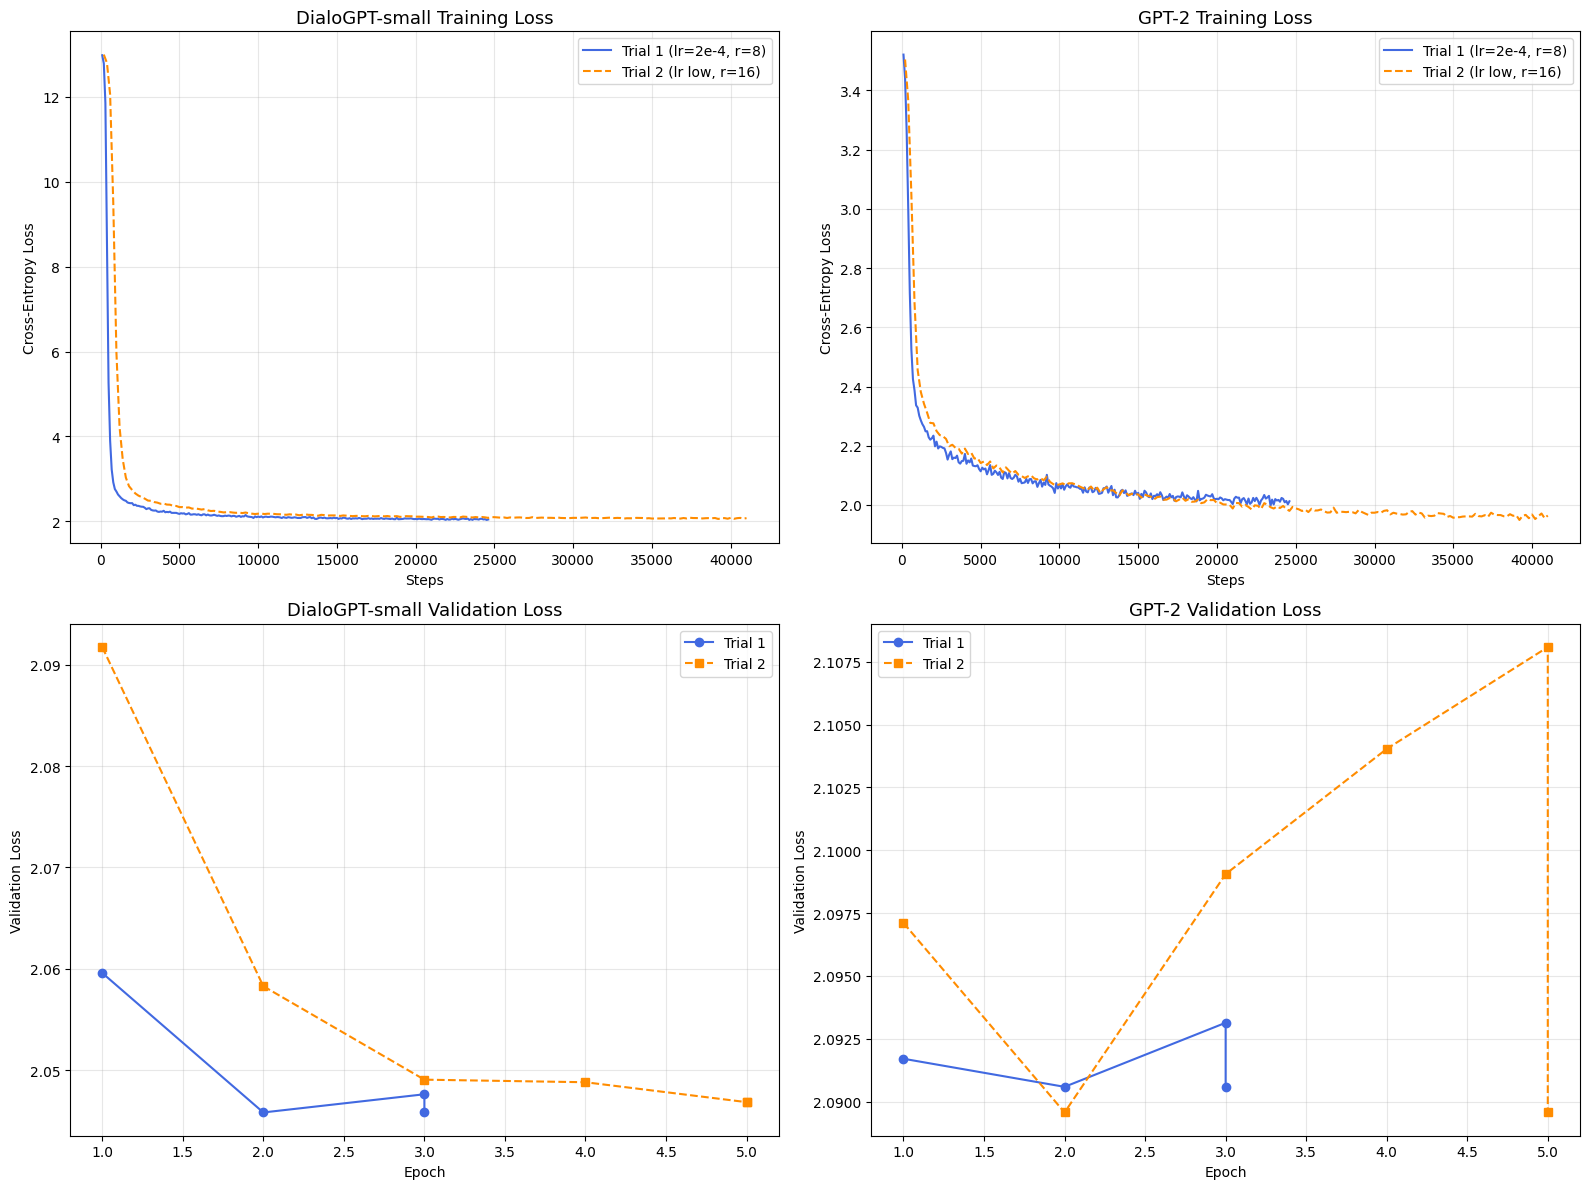

In [27]:
hg1t1 = get_training_history(trainer_g1_t1)
hg1t2 = get_training_history(trainer_g1_t2)
hg2t1 = get_training_history(trainer_g2_t1)
hg2t2 = get_training_history(trainer_g2_t2)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, h_a, h_b, title in [
    (axes[0,0], hg1t1, hg1t2, 'DialoGPT-small Training Loss'),
    (axes[0,1], hg2t1, hg2t2, 'GPT-2 Training Loss'),
]:
    ax.plot(h_a['steps'], h_a['train_loss'], label='Trial 1 (lr=2e-4, r=8)', color='royalblue')
    ax.plot(h_b['steps'], h_b['train_loss'], label='Trial 2 (lr low, r=16)', color='darkorange', linestyle='--')
    ax.set_title(title, fontsize=13); ax.set_xlabel('Steps'); ax.set_ylabel('Cross-Entropy Loss')
    ax.legend(); ax.grid(alpha=0.3)

for ax, h_a, h_b, title in [
    (axes[1,0], hg1t1, hg1t2, 'DialoGPT-small Validation Loss'),
    (axes[1,1], hg2t1, hg2t2, 'GPT-2 Validation Loss'),
]:
    ax.plot(h_a['epochs'], h_a['eval_loss'], 'o-', label='Trial 1', color='royalblue')
    ax.plot(h_b['epochs'], h_b['eval_loss'], 's--', label='Trial 2', color='darkorange')
    ax.set_title(title, fontsize=13); ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Loss')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('generation_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()


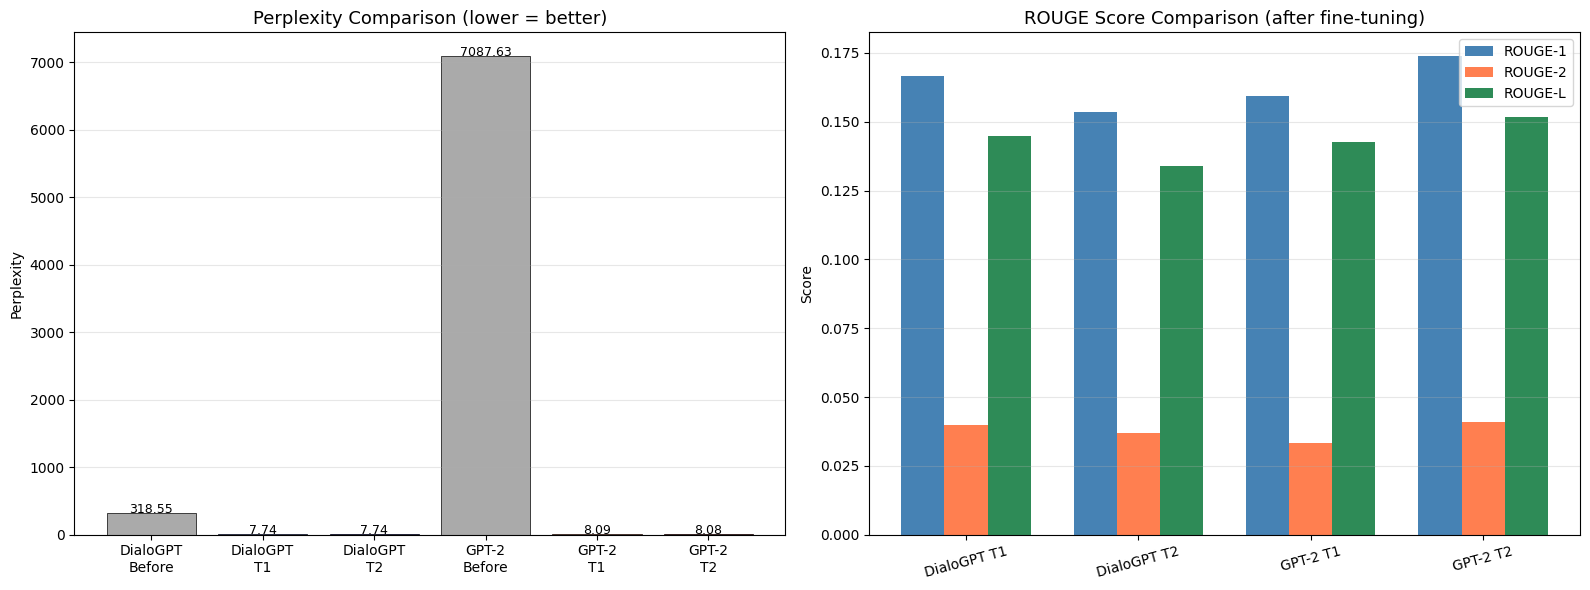

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Perplexity bar chart
model_labels = ['DialoGPT\nBefore', 'DialoGPT\nT1', 'DialoGPT\nT2',
                'GPT-2\nBefore', 'GPT-2\nT1', 'GPT-2\nT2']
ppl_vals = [ppl_before_g1, ppl_g1_t1, ppl_g1_t2, ppl_before_g2, ppl_g2_t1, ppl_g2_t2]
colors   = ['#aaa','royalblue','darkblue','#aaa','coral','darkred']
axes[0].bar(model_labels, ppl_vals, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Perplexity Comparison (lower = better)', fontsize=13)
axes[0].set_ylabel('Perplexity'); axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(ppl_vals):
    axes[0].text(i, v+0.5, str(v), ha='center', fontsize=9)

# ROUGE grouped bar chart
configs = ['DialoGPT T1', 'DialoGPT T2', 'GPT-2 T1', 'GPT-2 T2']
r1 = [rouge_g1_t1['rouge1'], rouge_g1_t2['rouge1'], rouge_g2_t1['rouge1'], rouge_g2_t2['rouge1']]
r2 = [rouge_g1_t1['rouge2'], rouge_g1_t2['rouge2'], rouge_g2_t1['rouge2'], rouge_g2_t2['rouge2']]
rl = [rouge_g1_t1['rougeL'], rouge_g1_t2['rougeL'], rouge_g2_t1['rougeL'], rouge_g2_t2['rougeL']]

x   = np.arange(len(configs))
w   = 0.25
axes[1].bar(x - w, r1, w, label='ROUGE-1', color='steelblue')
axes[1].bar(x,     r2, w, label='ROUGE-2', color='coral')
axes[1].bar(x + w, rl, w, label='ROUGE-L', color='seagreen')
axes[1].set_title('ROUGE Score Comparison (after fine-tuning)', fontsize=13)
axes[1].set_xticks(x); axes[1].set_xticklabels(configs, rotation=15)
axes[1].set_ylabel('Score'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('generation_metrics.png', dpi=120, bbox_inches='tight')
plt.show()


In [29]:
# ---- Example: Before vs After Fine-tuning ----
def show_generation(model, tokenizer, context, label=''):
    model.eval()
    enc = tokenizer(context, return_tensors='pt', max_length=200, truncation=True).to(device)
    with torch.no_grad():
        out = model.generate(
            **enc, max_new_tokens=60, do_sample=True,
            temperature=0.7, top_p=0.9,
            pad_token_id=tokenizer.eos_token_id
        )
    gen = tokenizer.decode(out[0][enc['input_ids'].shape[1]:], skip_special_tokens=True)
    print(f'  [{label}]: {gen}')
    return gen

test_prompts = [
    '[PERSONA] i enjoy hiking in the mountains. [PERSONA] i have two dogs named max and luna. '
    '[HISTORY] hi! what do you love doing in your free time? [RESPONSE]',
    '[PERSONA] i work as a nurse at a city hospital. [PERSONA] i love cooking italian food. '
    '[HISTORY] what kind of work do you do? [RESPONSE]',
    '[PERSONA] i am passionate about reading science fiction books. [PERSONA] i play guitar on weekends. '
    '[HISTORY] hello! tell me something about yourself. [RESPONSE]',
]

# Load fresh base model for comparison
base_g1 = AutoModelForCausalLM.from_pretrained(GEN_MODEL1).to(device)
base_tok_g1 = AutoTokenizer.from_pretrained(GEN_MODEL1)
base_tok_g1.pad_token = base_tok_g1.eos_token

print('=' * 70)
print('EXAMPLE GENERATION COMPARISON: Before vs After Fine-tuning (DialoGPT)')
print('=' * 70)
for i, prompt in enumerate(test_prompts):
    print(f'\nPrompt {i+1}: {prompt[:100]}...')
    show_generation(base_g1,  base_tok_g1, prompt, label='Before FT')
    show_generation(gen1_t1,  tok_gen1,    prompt, label='After FT Trial 1')
    show_generation(gen1_t2,  tok_gen1,    prompt, label='After FT Trial 2')

del base_g1; torch.cuda.empty_cache()


EXAMPLE GENERATION COMPARISON: Before vs After Fine-tuning (DialoGPT)

Prompt 1: [PERSONA] i enjoy hiking in the mountains. [PERSONA] i have two dogs named max and luna. [HISTORY] h...
  [Before FT]:  i love hiking in the mountains.
  [After FT Trial 1]:  i love to hike, especially hiking. what about you? i am a vet... i love hiking..... i am a dog lover............................
  [After FT Trial 2]:  i like hiking and hiking. i like to hike. you??? [SEP] i'm a long time outdoorsist. i've been hiking for over a year. you???????!!?!!!!!!!!!!!!!

Prompt 2: [PERSONA] i work as a nurse at a city hospital. [PERSONA] i love cooking italian food. [HISTORY] wha...
  [Before FT]:  i work as a nurse at a city hospital.
  [After FT Trial 1]:  i'm a nurse at a hospital. what about you? [SEP] i work as a nurse. i love cooking. what do you do? i'm a nurse. what about you? [SEP] i'm a nurse at a hospital. i'm an aspiring nurse. i am
  [After FT Trial 2]:  i work as a nurse, so i cook italian food.

In [30]:
# Generation summary table
summary_gen = pd.DataFrame({
    'Model':         ['DialoGPT-small']*3 + ['GPT-2']*3,
    'Configuration': ['Before FT','Trial1(lr=2e-4,r=8,ep=3)','Trial2(lr=5e-5,r=16,ep=5)',
                       'Before FT','Trial1(lr=2e-4,r=8,ep=3)','Trial2(lr=1e-4,r=16,ep=5)'],
    'Perplexity':    [ppl_before_g1, ppl_g1_t1, ppl_g1_t2, ppl_before_g2, ppl_g2_t1, ppl_g2_t2],
    'ROUGE-1':       ['N/A', f'{rouge_g1_t1["rouge1"]:.4f}', f'{rouge_g1_t2["rouge1"]:.4f}',
                       'N/A', f'{rouge_g2_t1["rouge1"]:.4f}', f'{rouge_g2_t2["rouge1"]:.4f}'],
    'ROUGE-2':       ['N/A', f'{rouge_g1_t1["rouge2"]:.4f}', f'{rouge_g1_t2["rouge2"]:.4f}',
                       'N/A', f'{rouge_g2_t1["rouge2"]:.4f}', f'{rouge_g2_t2["rouge2"]:.4f}'],
    'ROUGE-L':       ['N/A', f'{rouge_g1_t1["rougeL"]:.4f}', f'{rouge_g1_t2["rougeL"]:.4f}',
                       'N/A', f'{rouge_g2_t1["rougeL"]:.4f}', f'{rouge_g2_t2["rougeL"]:.4f}'],
})
print('\n' + '='*90)
print('GENERATION RESULTS SUMMARY')
print('='*90)
print(summary_gen.to_string(index=False))



GENERATION RESULTS SUMMARY
         Model             Configuration  Perplexity ROUGE-1 ROUGE-2 ROUGE-L
DialoGPT-small                 Before FT      318.55     N/A     N/A     N/A
DialoGPT-small  Trial1(lr=2e-4,r=8,ep=3)        7.74  0.1668  0.0399  0.1448
DialoGPT-small Trial2(lr=5e-5,r=16,ep=5)        7.74  0.1535  0.0370  0.1340
         GPT-2                 Before FT     7087.63     N/A     N/A     N/A
         GPT-2  Trial1(lr=2e-4,r=8,ep=3)        8.09  0.1594  0.0333  0.1428
         GPT-2 Trial2(lr=1e-4,r=16,ep=5)        8.08  0.1738  0.0409  0.1517


---
## Section 4: Final Comparative Overview


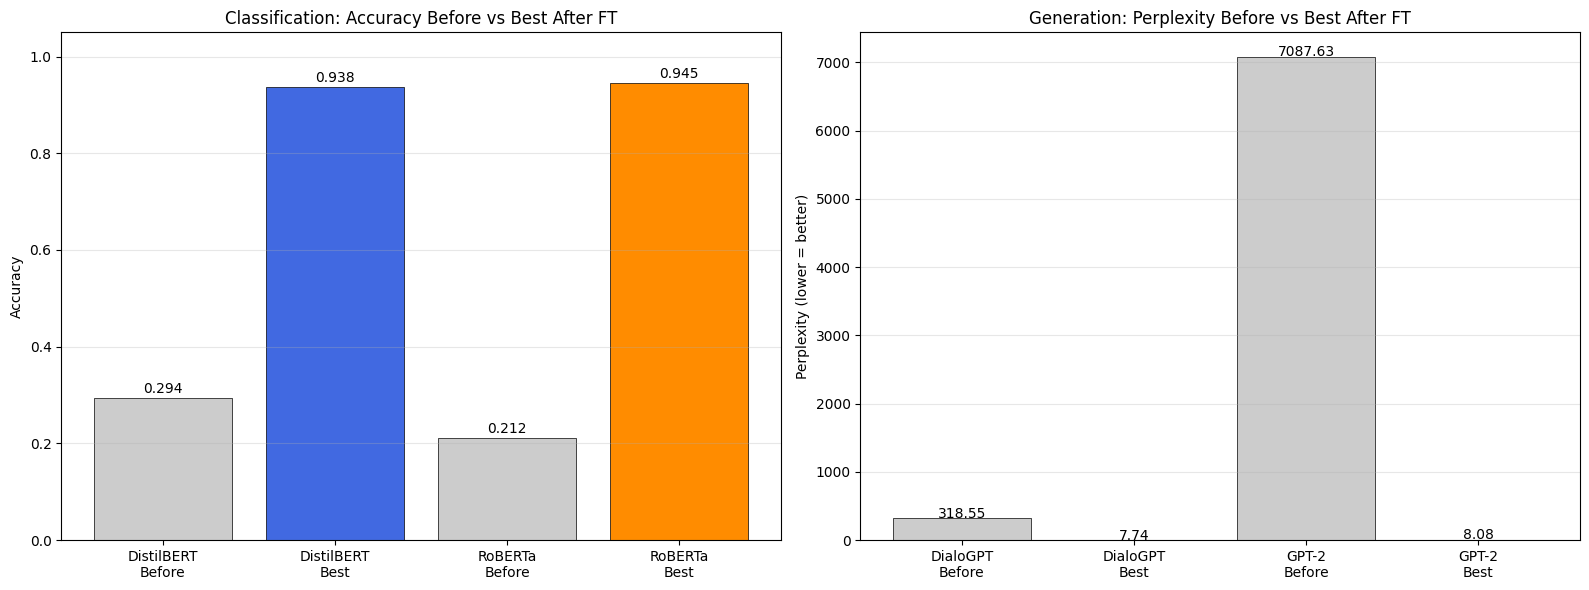


All experiments complete. Summary figures saved.

Classification — Best DistilBERT: 0.9379 | Best RoBERTa: 0.9454
Generation    — Best DialoGPT PPL: 7.74 | Best GPT-2 PPL: 8.08


In [31]:
# Combined bar chart comparing all models across key metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Classification accuracy improvement
cls_models   = ['DistilBERT\nBefore', 'DistilBERT\nBest', 'RoBERTa\nBefore', 'RoBERTa\nBest']
best_dist    = max(res1_t1['eval_accuracy'], res1_t2['eval_accuracy'])
best_roberta = max(res2_t1['eval_accuracy'], res2_t2['eval_accuracy'])
cls_vals     = [acc_b1, best_dist, acc_b2, best_roberta]
cls_colors   = ['#ccc','royalblue','#ccc','darkorange']

bars = axes[0].bar(cls_models, cls_vals, color=cls_colors, edgecolor='black', linewidth=0.5)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Classification: Accuracy Before vs Best After FT', fontsize=12)
axes[0].set_ylabel('Accuracy')
for bar, val in zip(bars, cls_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}', ha='center', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Generation perplexity improvement
best_dialo_ppl = min(ppl_g1_t1, ppl_g1_t2)
best_gpt2_ppl  = min(ppl_g2_t1, ppl_g2_t2)
gen_models  = ['DialoGPT\nBefore', 'DialoGPT\nBest', 'GPT-2\nBefore', 'GPT-2\nBest']
gen_vals    = [ppl_before_g1, best_dialo_ppl, ppl_before_g2, best_gpt2_ppl]
gen_colors  = ['#ccc','royalblue','#ccc','darkorange']

bars2 = axes[1].bar(gen_models, gen_vals, color=gen_colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Generation: Perplexity Before vs Best After FT', fontsize=12)
axes[1].set_ylabel('Perplexity (lower = better)')
for bar, val in zip(bars2, gen_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.5, str(val), ha='center', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nAll experiments complete. Summary figures saved.')
print(f'\nClassification — Best DistilBERT: {best_dist:.4f} | Best RoBERTa: {best_roberta:.4f}')
print(f'Generation    — Best DialoGPT PPL: {best_dialo_ppl} | Best GPT-2 PPL: {best_gpt2_ppl}')
